In [1]:
import os

train_data_path =r"C:\Deep_Learning\Spots Detection - CNN'\Acne vs Non_Acne\train"
validation_data_path = r"C:\Deep_Learning\Spots Detection - CNN'\Acne vs Non_Acne\validation"

os.makedirs('model', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('faces/with_acne', exist_ok=True)
os.makedirs('faces/without_acne', exist_ok=True)
os.makedirs('faces', exist_ok=True)

In [2]:
import matplotlib.pyplot as plt

def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

training_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

training_data = training_datagen.flow_from_directory(
    train_data_path,
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical'
)

Found 7000 images belonging to 2 classes.


In [4]:
print("Class Indices:", training_data.class_indices)

Class Indices: {'Acne': 0, 'Non_Acne': 1}


In [5]:
valid_datagen = ImageDataGenerator(rescale=1./255)

valid_data = valid_datagen.flow_from_directory(
    validation_data_path,
    target_size=(200, 200),
    batch_size=32,
    class_mode='categorical'
)

Found 1500 images belonging to 2 classes.


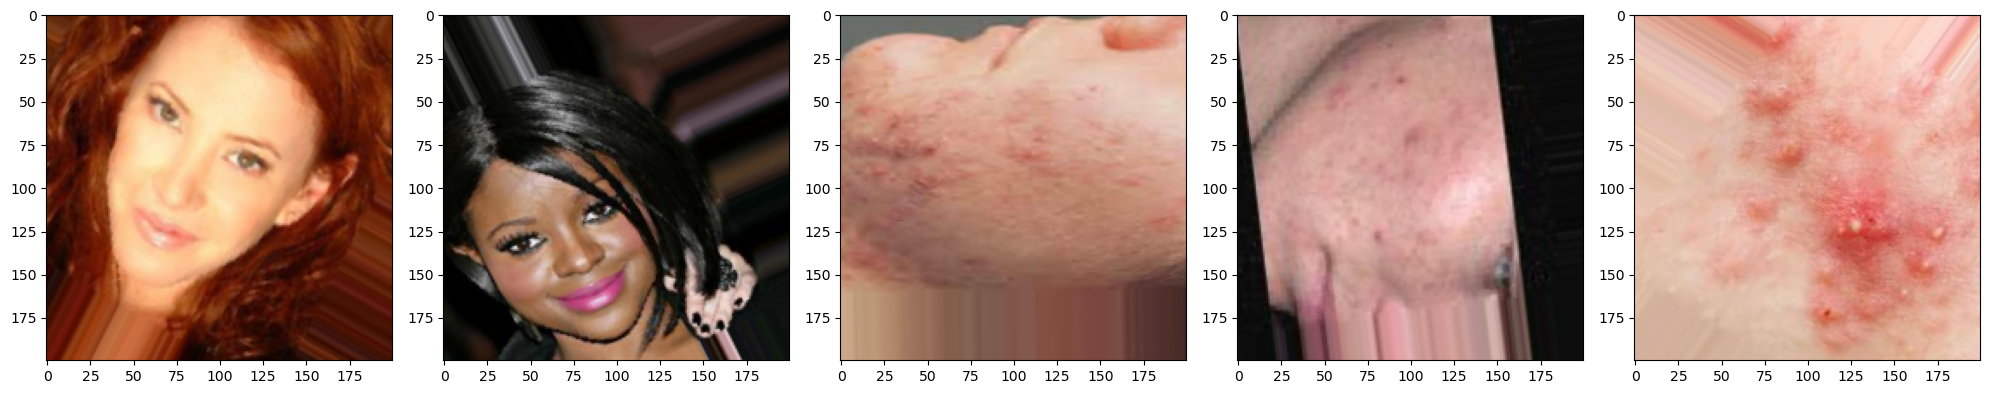

In [6]:
images = [training_data[0][0][i] for i in range(5)]
plotImages(images)

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint

model_path = 'model/acne_model.h5'
checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)
callbacks_list = [checkpoint]

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam

# CNN Model
cnn_model = keras.models.Sequential([
    keras.layers.Conv2D(filters=32, kernel_size=5, activation='relu', input_shape=[200, 200, 3]),
    keras.layers.MaxPooling2D(pool_size=(4, 4)),

    keras.layers.Conv2D(filters=64, kernel_size=4, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(3, 3)),

    keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=256, kernel_size=2, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(units=256, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(units=2, activation='softmax')  # 2 classes: with_acne / without_acne
])

cnn_model.summary()

c:\Users\great\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 196, 196, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 256)      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,186 (1.55 MB)

 Trainable params: 405,186 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = cnn_model.fit(
    training_data,
    epochs=50,
    verbose=1,
    validation_data=valid_data,
    callbacks=callbacks_list
)

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7211 - loss: 0.4863
Epoch 1: val_accuracy improved from None to 0.95667, saving model to model/acne_model.h5



Epoch 1: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 115s 509ms/step - accuracy: 0.8517 - loss: 0.3131 - val_accuracy: 0.9567 - val_loss: 0.1443
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9538 - loss: 0.1360
Epoch 2: val_accuracy improved from 0.95667 to 0.96667, saving model to model/acne_model.h5



Epoch 2: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 477ms/step - accuracy: 0.9559 - loss: 0.1268 - val_accuracy: 0.9667 - val_loss: 0.0947
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9591 - loss: 0.1084
Epoch 3: val_accuracy did not improve from 0.96667
219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 476ms/step - accuracy: 0.9611 - loss: 0.1042 - val_accuracy: 0.9533 - val_loss: 0.1268
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9658 - loss: 0.0917
Epoch 4: val_accuracy did not improve from 0.96667
219/219 ━━━━━━━━━━━━━━━━━━━━ 108s 491ms/step - accuracy: 0.9703 - loss: 0.0809 - val_accuracy: 0.9620 - val_loss: 0.0999
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9705 - loss: 0.0843
Epoch 5: val_accuracy did not improve from 0.96667
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 483ms/step - accuracy: 0.9723 - loss: 0.0804 - val_accuracy: 0.9580 - val_loss: 0.1151
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 4


Epoch 6: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 481ms/step - accuracy: 0.9763 - loss: 0.0709 - val_accuracy: 0.9720 - val_loss: 0.0844
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9804 - loss: 0.0541
Epoch 7: val_accuracy improved from 0.97200 to 0.98067, saving model to model/acne_model.h5



Epoch 7: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 478ms/step - accuracy: 0.9809 - loss: 0.0557 - val_accuracy: 0.9807 - val_loss: 0.0632
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9840 - loss: 0.0499
Epoch 8: val_accuracy improved from 0.98067 to 0.98267, saving model to model/acne_model.h5


...


Epoch 10: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 474ms/step - accuracy: 0.9794 - loss: 0.0559 - val_accuracy: 0.9893 - val_loss: 0.0286
Epoch 11/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.9800 - loss: 0.0564
Epoch 11: val_accuracy did not improve from 0.98933
219/219 ━━━━━━━━━━━━━━━━━━━━ 137s 625ms/step - accuracy: 0.9816 - loss: 0.0506 - val_accuracy: 0.9853 - val_loss: 0.0402
Epoch 12/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - accuracy: 0.9819 - loss: 0.0492
Epoch 12: val_accuracy did not improve from 0.98933
219/219 ━━━━━━━━━━━━━━━━━━━━ 175s 797ms/step - accuracy: 0.9841 - loss: 0.0433 - val_accuracy: 0.9880 - val_loss: 0.0327
Epoch 13/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.9821 - loss: 0.0504
Epoch 13: val_accuracy did not improve from 0.98933
219/219 ━━━━━━━━━━━━━━━━━━━━ 125s 569ms/step - accuracy: 0.9809 - loss: 0.0551 - val_accuracy: 0.9767 - val_loss: 0.0620
Epoch 14/50
219/219 ━━━━━━━━━━━━━━━━━


Epoch 19: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 477ms/step - accuracy: 0.9851 - loss: 0.0403 - val_accuracy: 0.9920 - val_loss: 0.0272
Epoch 20/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9886 - loss: 0.0316
Epoch 20: val_accuracy improved from 0.99200 to 0.99400, saving model to model/acne_model.h5



Epoch 20: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 478ms/step - accuracy: 0.9881 - loss: 0.0344 - val_accuracy: 0.9940 - val_loss: 0.0173
Epoch 21/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9894 - loss: 0.0319
Epoch 21: val_accuracy did not improve from 0.99400
219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 476ms/step - accuracy: 0.9859 - loss: 0.0378 - val_accuracy: 0.9813 - val_loss: 0.0540
Epoch 22/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9875 - loss: 0.0371
Epoch 22: val_accuracy did not improve from 0.99400
219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 475ms/step - accuracy: 0.9870 - loss: 0.0362 - val_accuracy: 0.9940 - val_loss: 0.0142
Epoch 23/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9891 - loss: 0.0287
Epoch 23: val_accuracy did not improve from 0.99400
219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 476ms/step - accuracy: 0.9873 - loss: 0.0350 - val_accuracy: 0.9833 - val_loss: 0.0514
Epoch 24/50
219/219 ━━━━━━━━━━━━━━━━━


Epoch 24: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 476ms/step - accuracy: 0.9887 - loss: 0.0320 - val_accuracy: 0.9947 - val_loss: 0.0162
Epoch 25/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9899 - loss: 0.0328
Epoch 25: val_accuracy did not improve from 0.99467
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 483ms/step - accuracy: 0.9874 - loss: 0.0391 - val_accuracy: 0.9880 - val_loss: 0.0319
Epoch 26/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9852 - loss: 0.0323
Epoch 26: val_accuracy did not improve from 0.99467
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 480ms/step - accuracy: 0.9869 - loss: 0.0301 - val_accuracy: 0.9913 - val_loss: 0.0282
Epoch 27/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9855 - loss: 0.0365
Epoch 27: val_accuracy did not improve from 0.99467
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 479ms/step - accuracy: 0.9873 - loss: 0.0356 - val_accuracy: 0.9813 - val_loss: 0.0821
Epoch 28/50
219/219 ━━━━━━━━━━━━━━━━━


Epoch 40: finished saving model to model/acne_model.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 117s 536ms/step - accuracy: 0.9923 - loss: 0.0270 - val_accuracy: 0.9960 - val_loss: 0.0126
Epoch 41/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9920 - loss: 0.0193
Epoch 41: val_accuracy did not improve from 0.99600
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 483ms/step - accuracy: 0.9913 - loss: 0.0237 - val_accuracy: 0.9793 - val_loss: 0.0702
Epoch 42/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9937 - loss: 0.0186
Epoch 42: val_accuracy did not improve from 0.99600
219/219 ━━━━━━━━━━━━━━━━━━━━ 107s 489ms/step - accuracy: 0.9927 - loss: 0.0249 - val_accuracy: 0.9860 - val_loss: 0.0454
Epoch 43/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9872 - loss: 0.0416
Epoch 43: val_accuracy did not improve from 0.99600
219/219 ━━━━━━━━━━━━━━━━━━━━ 106s 484ms/step - accuracy: 0.9871 - loss: 0.0375 - val_accuracy: 0.9920 - val_loss: 0.0249
Epoch 44/50
219/219 ━━━━━━━━━━━━━━━━━

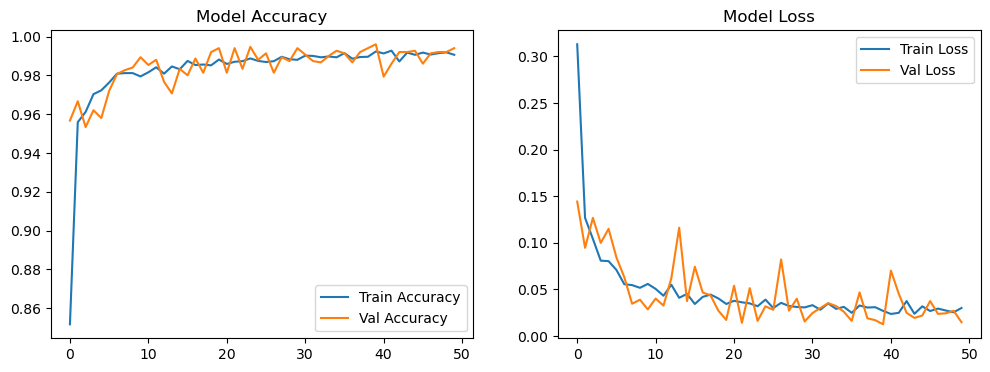

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [12]:
cnn_model.save('models/acne_model_last.h5')
print("Model save ho gaya")

Model save ho gaya


In [20]:
import cv2
import numpy as np
from keras.models import load_model
from keras.preprocessing.image import load_img, img_to_array

model = load_model('model/acne_model.h5')

img_width, img_height = 200, 200

haarcascade_path = r"C:\Deep_Learning\Mask Detection - CNN\haarcascade_frontalface_default (1).xml"
face_cascade = cv2.CascadeClassifier(haarcascade_path)

print("Model aur Cascade loaded!")

Model aur Cascade loaded!


In [21]:

cap = cv2.VideoCapture(0)

font = cv2.FONT_HERSHEY_SIMPLEX
fontScale = 1
thickness = 2
img_count_full = 0

while True:
    img_count_full += 1

    response, color_img = cap.read()

    if not response:
        print("Webcam se image nahi mili, band ho raha hai...")
        break

    gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_img, 1.1, 6)

    img_count = 0
    for (x, y, w, h) in faces:
        img_count += 1
        org = (x - 10, max(y - 10, 0))

        color_face = color_img[y:y+h, x:x+w]

        face_path = f'faces/temp_face_{img_count_full}_{img_count}.jpg'
        cv2.imwrite(face_path, color_face)

        img = load_img(face_path, target_size=(img_width, img_height))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred_prob = model.predict(img_array, verbose=0)
        pred = np.argmax(pred_prob)

        if pred == 0:
            class_label = "Acne Detected"
            box_color = (0, 0, 255)   # Red - acne hai
            text_color = (0, 0, 255)
            cv2.imwrite(f'faces/with_acne/{img_count_full}_{img_count}.jpg', color_face)
        else:
            class_label = "Clear Skin"
            box_color = (0, 255, 0)   # Green - clear skin
            text_color = (0, 255, 0)
            cv2.imwrite(f'faces/without_acne/{img_count_full}_{img_count}.jpg', color_face)

        cv2.rectangle(color_img, (x, y), (x+w, y+h), box_color, 3)
        cv2.putText(color_img, class_label, org, font, fontScale, text_color, thickness, cv2.LINE_AA)

    cv2.imshow('Acne Detection - Q dabao band karne ke liye', color_img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("ho gaya")

ho gaya


GRU- Gradiant Recurrent unit